# PRADEEP KUMAR

# Predictive Forecasting of Care Load & Placement Demand

# Import Libraries #

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings("ignore")

# Load Dataset #

In [2]:
df = pd.read_csv (r"C:\Users\prade\projects\HHS_Unaccompanied_Alien_Children_Program.csv")

In [3]:
df.head(11)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0
5,"December 14, 2025",8.0,35.0,4.0,"2,462",8.0
6,"December 11, 2025",7.0,47.0,9.0,"2,437",10.0
7,"December 10, 2025",10.0,54.0,5.0,"2,439",9.0
8,"December 09, 2025",4.0,30.0,7.0,"2,443",8.0
9,"December 08, 2025",9.0,27.0,9.0,"2,440",4.0


# Exploring data 

In [4]:
df.shape

(1170, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [6]:
df.describe() 

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


# Data Cleaning   #

### Check Columns  Name ###

In [7]:
df.columns.tolist()

['Date',
 'Children apprehended and placed in CBP custody*',
 'Children in CBP custody',
 'Children transferred out of CBP custody',
 'Children in HHS Care',
 'Children discharged from HHS Care']

### Remove commas ##

In [8]:
# Remove Spaces from Column Names
df.columns = df.columns.str.strip()

### Convert Numeric Columns

In [9]:
numeric_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in numeric_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

### Convert Date ##

In [10]:
# Convert Date Column
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

### Handel Missing values ##


### Check the missing values

In [11]:
print(df.isnull().sum())

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


### Fill Missing Value #

### Replace Missing Dates 

In [12]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Date"] = df["Date"].fillna(method="ffill")

df["Date"] = df["Date"].fillna(method="bfill")

### Verify

In [13]:
df.isnull().sum()

Date                                                 0
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

### Convert Numeric Columns

In [14]:
numeric_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in numeric_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

### Replace missing values with  median  Because(Use Median better than Mean for time-series.) ###
### (Mode is generally not recommended for continuous numerical time-series data because it may repeat a single value too often.) ###
### (If there are spikes or outliers in care load data, median is more robust.) ###

In [15]:
df[col].fillna(
        df[col].median(),
        inplace=True
    )

### Verify

In [16]:
df.isnull().sum()

Date                                                 0
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                    0
dtype: int64

#### Fill Any Remaining Missing Values WITH MEAN

In [17]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

### Verify

In [18]:
print(df.isnull().sum())

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


### Duplicates ##

In [19]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 449


### Remove Duplicates

In [20]:
df = df.drop_duplicates()

### verify

In [21]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


### Set Date Index

In [22]:
df = df.set_index("Date")

### Dataset Overview

In [23]:
df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-22,32.0,49.0,39.0,7122.0,227.0
2023-01-23,32.0,50.0,39.0,7280.0,181.0
2023-01-24,47.0,42.0,47.0,7433.0,175.0
2023-01-25,20.0,22.0,41.0,7538.0,180.0


In [24]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,721.000000,721.000000,721.000000,721.000000,721.000000
mean,93.523611,171.494444,128.668056,6061.275000,173.417476
std,72.596158,126.267188,97.254403,2831.102015,125.615835
min,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,12.000000,36.000000,14.000000,2468.000000,20.000000
50%,99.000000,190.000000,157.000000,6405.000000,181.000000
75%,147.000000,263.000000,199.000000,8008.000000,267.000000
max,333.000000,531.000000,440.000000,11516.000000,505.000000


# EDA #

### Trend charts ##

### Trend Chart (HHS Care)

In [25]:
px.line(
    df,
    y="Children in HHS Care",
    title="Children in HHS Care Trend"
).show()

### Transfer Trend

In [26]:
px.line(
    df,
    y="Children transferred out of CBP custody",
    title="Transfer Trend"
).show()

### Discharge Trend

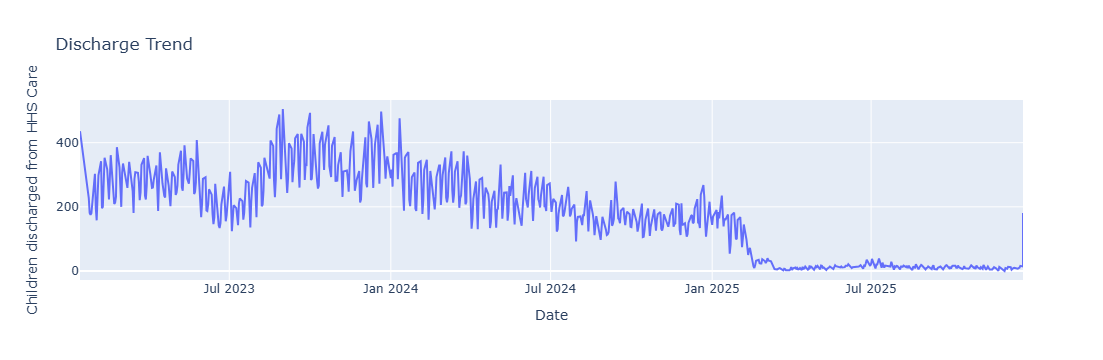

In [27]:
px.line(
    df,
    y="Children discharged from HHS Care",
    title="Discharge Trend"
).show()

### Histograms ##

In [28]:
px.histogram(
    df,
    x="Children in HHS Care",
    nbins=30,
    title="Distribution of HHS Care"
).show()

### Correlation heatmap ##

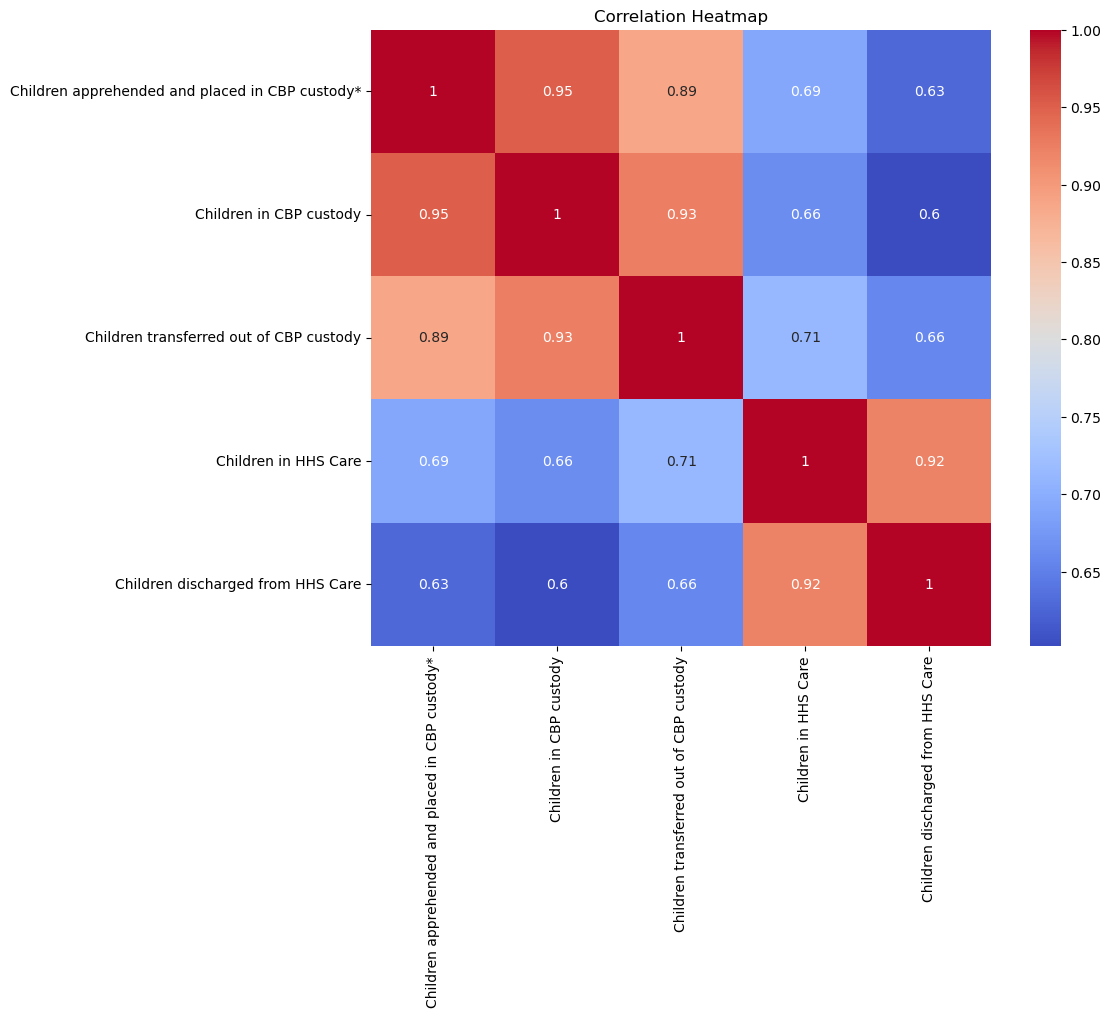

In [29]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Seasonal decomposition ##

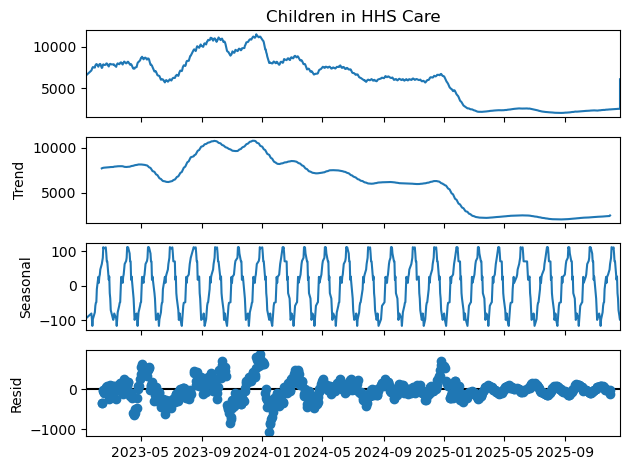

In [30]:
result = seasonal_decompose(
    df["Children in HHS Care"],
    model="additive",
    period=30
)

result.plot()

plt.show()

# Feature Engineering #

### Lag 1, 7, 14

In [31]:
df["lag_1"] = df["Children in HHS Care"].shift(1)

df["lag_7"] = df["Children in HHS Care"].shift(7)

df["lag_14"] = df["Children in HHS Care"].shift(14)

### Rolling Mean 7, 14

In [32]:
df["rolling_mean_7"] = (
    df["Children in HHS Care"]
    .rolling(7)
    .mean()
)

df["rolling_mean_14"] = (
    df["Children in HHS Care"]
    .rolling(14)
    .mean()
)

### Net Pressure

In [33]:
df["Net_Pressure"] = (
    df["Children transferred out of CBP custody"]
    -
    df["Children discharged from HHS Care"]
)

### DayOfWeek

In [34]:
df["DayOfWeek"] = df.index.dayofweek

### Month

In [35]:
df["Month"] = df.index.month

# Train-Test Split (time-based) #

### Remove NA Created by Lag Features

In [36]:
df = df.dropna()

### Define Target

In [37]:
y = df["Children in HHS Care"]

### Define Features

In [38]:
X = df.drop(
    columns=["Children in HHS Care"]
)

### Time Based Split

In [39]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]

X_test = X.iloc[split:]

y_train = y.iloc[:split]

y_test = y.iloc[split:]

# Models #

### Naive Forecast

In [40]:
naive_pred = y_test.shift(1)

naive_pred = naive_pred.fillna(method="bfill")

### ARIMA

In [41]:
arima_model = ARIMA(
    y_train,
    order=(5,1,2)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(y_test)
)

### Exponential Smoothing

In [42]:
exp_model = ExponentialSmoothing(
    y_train,
    trend="add"
)

exp_fit = exp_model.fit()

exp_pred = exp_fit.forecast(
    len(y_test)
)

### Random Forest

In [43]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

### Gradient Boosting

In [44]:
gb = GradientBoostingRegressor()

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(X_test)

# Evaluation #

### MAE,RMSE,MAPE

In [45]:
def evaluate(actual, pred):

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    mape = mean_absolute_percentage_error(
        actual,
        pred
    )

    return mae, rmse, mape

### Evaluate All Models

In [46]:
print("Naive:", evaluate(y_test, naive_pred))

print("ARIMA:", evaluate(y_test, arima_pred))

print("Exponential:", evaluate(y_test, exp_pred))

print("Random Forest:", evaluate(y_test, rf_pred))

print("Gradient Boosting:", evaluate(y_test, gb_pred))

Naive: (35.28362676056338, np.float64(300.52104312935614), 0.008628253918149519)
ARIMA: (298.7350573569622, np.float64(440.6894784137596), 0.13286023014259515)
Exponential: (935.5313417571216, np.float64(1042.2862403464187), 0.41996791909155323)
Random Forest: (86.46538732394367, np.float64(287.8050416364752), 0.033316686529457254)
Gradient Boosting: (79.59349710341932, np.float64(297.61219344515473), 0.029621888684913177)


# Actual vs Predicted Visualization

### Random Forest Example

In [47]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred
})

px.line(
    results,
    title="Actual vs Predicted"
).show()

# Future 30-Day Forecast

In [48]:
future_forecast = exp_fit.forecast(30)

print(future_forecast)



565    2447.355668
566    2457.711337
567    2468.067005
568    2478.422674
569    2488.778343
570    2499.134011
571    2509.489680
572    2519.845348
573    2530.201017
574    2540.556685
575    2550.912354
576    2561.268022
577    2571.623691
578    2581.979360
579    2592.335028
580    2602.690697
581    2613.046365
582    2623.402034
583    2633.757702
584    2644.113371
585    2654.469039
586    2664.824708
587    2675.180377
588    2685.536045
589    2695.891714
590    2706.247382
591    2716.603051
592    2726.958719
593    2737.314388
594    2747.670056
dtype: float64


### Visualization

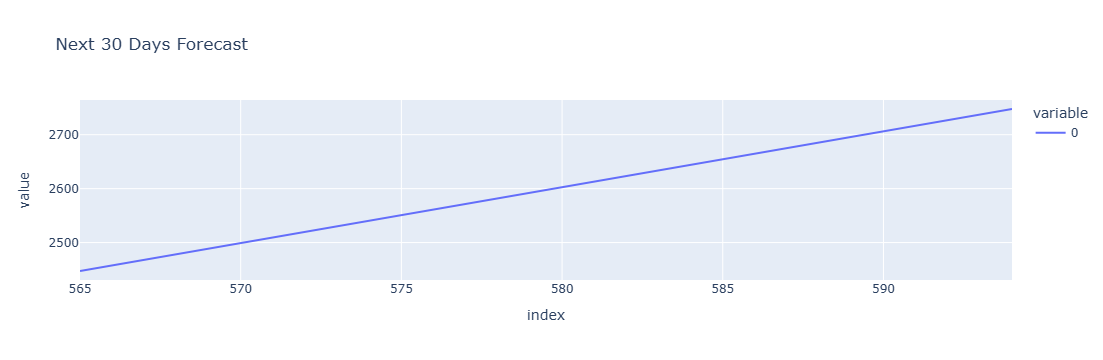

In [49]:
px.line(
    future_forecast,
    title="Next 30 Days Forecast"
).show()

### Capacity Stress KPI

In [50]:
df["Stress_Flag"] = np.where(
    df["Net_Pressure"] > 0,
    1,
    0
)



### Stress Probability

In [51]:
stress_probability = (
    df["Stress_Flag"].mean()
    * 100
)

print(
    "Capacity Stress Probability:",
    round(stress_probability,2),
    "%"
)

Capacity Stress Probability: 33.66 %


# Model Comparison Table

In [52]:
comparison = pd.DataFrame({

    "Model":[
        "Naive",
        "ARIMA",
        "Exponential",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        evaluate(y_test,naive_pred)[0],
        evaluate(y_test,arima_pred)[0],
        evaluate(y_test,exp_pred)[0],
        evaluate(y_test,rf_pred)[0],
        evaluate(y_test,gb_pred)[0]
    ],

    "RMSE":[
        evaluate(y_test,naive_pred)[1],
        evaluate(y_test,arima_pred)[1],
        evaluate(y_test,exp_pred)[1],
        evaluate(y_test,rf_pred)[1],
        evaluate(y_test,gb_pred)[1]
    ],

    "MAPE":[
        evaluate(y_test,naive_pred)[2],
        evaluate(y_test,arima_pred)[2],
        evaluate(y_test,exp_pred)[2],
        evaluate(y_test,rf_pred)[2],
        evaluate(y_test,gb_pred)[2]
    ]
})

comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,MAPE
3,Random Forest,86.465387,287.805042,0.033317
4,Gradient Boosting,79.593497,297.612193,0.029622
0,Naive,35.283627,300.521043,0.008628
1,ARIMA,298.735057,440.689478,0.132860
2,Exponential,935.531342,1042.286240,0.419968


In [53]:
#Export Final Dataset
df.to_csv(
    "Predictive Forecasting of Care Load & Placement Demand.csv"
)

# PRADEEP KUMAR

## Predictive Forecasting of Care Load & Placement Demand ##